In [247]:
import pandas as pd
import numpy as np
import seaborn as sns
import json

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from matplotlib import pyplot as plt
from pathlib import Path

## Loading of Data

### CASH Output

In [257]:
DATA_DIR = Path("C:/Users/P70099789/Projects/games-and-genes/data/")
RESULT_DIR = Path("C:/Users/P70099789/Projects/games-and-genes/results/")
DATASET = "E-MTAB-6698"
RUN = "latest"
COMPARISON = "normal_vs_tumor"
DIRECTION = "plus"

# DATA_DIR = Path("C:/Users/P70099789/Projects/games-and-genes/data/")
# RESULT_DIR = Path("C:/Users/P70099789/Projects/games-and-genes/results/")
# DATASET = "GSE42568"
# RUN = "latest"
# COMPARISON = "normal_vs_tumor"
# DIRECTION = "minus"

with open(RESULT_DIR / DATASET / RUN / "config.json") as f:
    config = json.load(f)
comparisons_by_name = {comp["experiment_name"]: comp for comp in config["comparisons"]}
comparison = comparisons_by_name[COMPARISON]

df_results = pd.read_csv(RESULT_DIR / DATASET / RUN / COMPARISON / DIRECTION / "results.csv", index_col=0)
df_results.head()

,shapley_case,shapley_control,observed_difference,observed_abs_difference,bootstrap_se,zscore,abs_zscore,pval,pval_adj
RFC2,0.000101,0.000065,0.000036,0.000036,0.000016,2.254873,2.254873,0.022,0.068775
HSPA6,0.000069,0.000041,0.000028,0.000028,0.000013,2.161630,2.161630,0.023,0.070919
PAX8,0.000024,0.000038,-0.000014,0.000014,0.000010,-1.481110,1.481110,0.145,0.264896
GUCA1A,0.000039,0.000049,-0.000009,0.000009,0.000012,-0.749087,0.749087,0.466,0.603503
THRA,0.000065,0.000028,0.000037,0.000037,0.000011,3.438242,3.438242,0.003,0.015517


In [258]:
def filter_and_sort_df(df: pd.DataFrame, pval_threshold=0.05) -> pd.DataFrame:
    df = df[df["pval"] < pval_threshold]
    df = df[df["shapley_case"] > df["shapley_case"].mean() + df["shapley_case"].std()]

    # return df.sort_values(["pval_adj", "abs_zscore"], ascending=[True, False])
    return df.sort_values("shapley_case", ascending=False)

df_results_filtered = filter_and_sort_df(df_results)

print(df_results_filtered.shape)
df_results_filtered.head()

(1599, 9)


,shapley_case,shapley_control,observed_difference,observed_abs_difference,bootstrap_se,zscore,abs_zscore,pval,pval_adj
INHBA,0.000217,0.000056,0.000161,0.000161,0.000014,11.428627,11.428627,0.0,0.0
FOXQ1,0.000213,0.000039,0.000174,0.000174,0.000013,13.815641,13.815641,0.0,0.0
CLDN1,0.000207,0.000043,0.000164,0.000164,0.000013,12.650039,12.650039,0.0,0.0
CEMIP,0.000207,0.000046,0.000160,0.000160,0.000014,11.588461,11.588461,0.0,0.0
AJUBA,0.000206,0.000051,0.000155,0.000155,0.000013,12.324456,12.324456,0.0,0.0


### Original Expression Data

In [259]:
df_expression = pd.read_csv(DATA_DIR / DATASET / config["expression_data_file"], index_col=0)
df_samples = pd.read_csv(DATA_DIR / DATASET / config["samples_data_file"], index_col=0)


group_column = comparison["group_column"]
allowed_groups = [comparison["case_value"], comparison["control_value"]]
df_samples = df_samples[df_samples[group_column].isin(allowed_groups)].copy()

df_expression = df_expression.loc[:, df_samples.index]
df_samples = df_samples.reindex(df_expression.columns)

In [260]:
df_expression.shape

(20545, 443)

## Analysis of CASh Output

### Unsupervised Sample Classification

In [261]:
true_labels = pd.Series(df_samples[comparison["group_column"]].map({comparison["case_value"]: 1, comparison["control_value"]: 0}), index=df_samples.index)
# true_labels = pd.Series(df_samples["tissue.ch1"].map({"normal breast": 0, "breast cancer": 1}), index=df_samples.index)

NUM_TOP_GENES = 100

df_results_filtered_top = df_results_filtered.head(min(len(df_results), NUM_TOP_GENES))

rng = np.random.default_rng(42)
random_genes = rng.choice(
    df_expression.index,
    size=min(NUM_TOP_GENES, len(df_expression.index)),
    replace=False,
)

top_genes = df_results_filtered_top.index.tolist()

In [262]:
def clustering_analysis(df: pd.DataFrame, genes: list, true_labels: pd.Series):
    df = df.loc[genes]
    X = df.T  
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled_df = pd.DataFrame(X_scaled, index=X.index, columns=X.columns)

    kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
    kmeans_labels = pd.Series(kmeans.fit_predict(X_scaled), index=X.index)

    true_lut = dict(zip(true_labels.unique(), sns.color_palette("Set1", len(true_labels.unique()))))
    true_colors = true_labels.map(true_lut)
    kmeans_lut = dict(zip(kmeans_labels.unique(), sns.color_palette("Set2", len(kmeans_labels.unique()))))
    kmeans_colors = kmeans_labels.map(kmeans_lut)
    annotation_colors = pd.DataFrame({
        'True Labels': true_colors,
        'KMeans': kmeans_colors
    })

    df_labels = true_labels.to_frame(name="true").join(kmeans_labels.to_frame(name="kmeans"))
    df_labels.corr()
    correlation = abs(df_labels.corr().iloc[0, 1])

    g = sns.clustermap(
        X_scaled_df.T, 
        col_colors=annotation_colors,
        figsize=(16, 14),
        cmap="coolwarm",
        z_score=None,          # Already scaled
        yticklabels=True,      # Show gene names
        xticklabels=False      # Hide sample names to avoid clutter
    )
    
    for label, color in true_lut.items():
        g.ax_col_dendrogram.bar(0, 0, color=color, label=f"True: {label}", linewidth=0)
    for label, color in kmeans_lut.items():
        g.ax_col_dendrogram.bar(0, 0, color=color, label=f"KMeans: {label}", linewidth=0)

    g.ax_col_dendrogram.legend(loc="center", ncol=2, bbox_to_anchor=(0.5, 1.2), frameon=False)
    g.ax_col_dendrogram.set_title(f"Correlation: {correlation:.2f}")
    plt.show()

    return kmeans_labels

c:\Users\P70099789\AppData\Local\miniconda3\envs\games-and-genes\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\P70099789\AppData\Local\miniconda3\envs\games-and-genes\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\Users\P70099789\AppData\Local\miniconda3\envs\games-and-genes\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


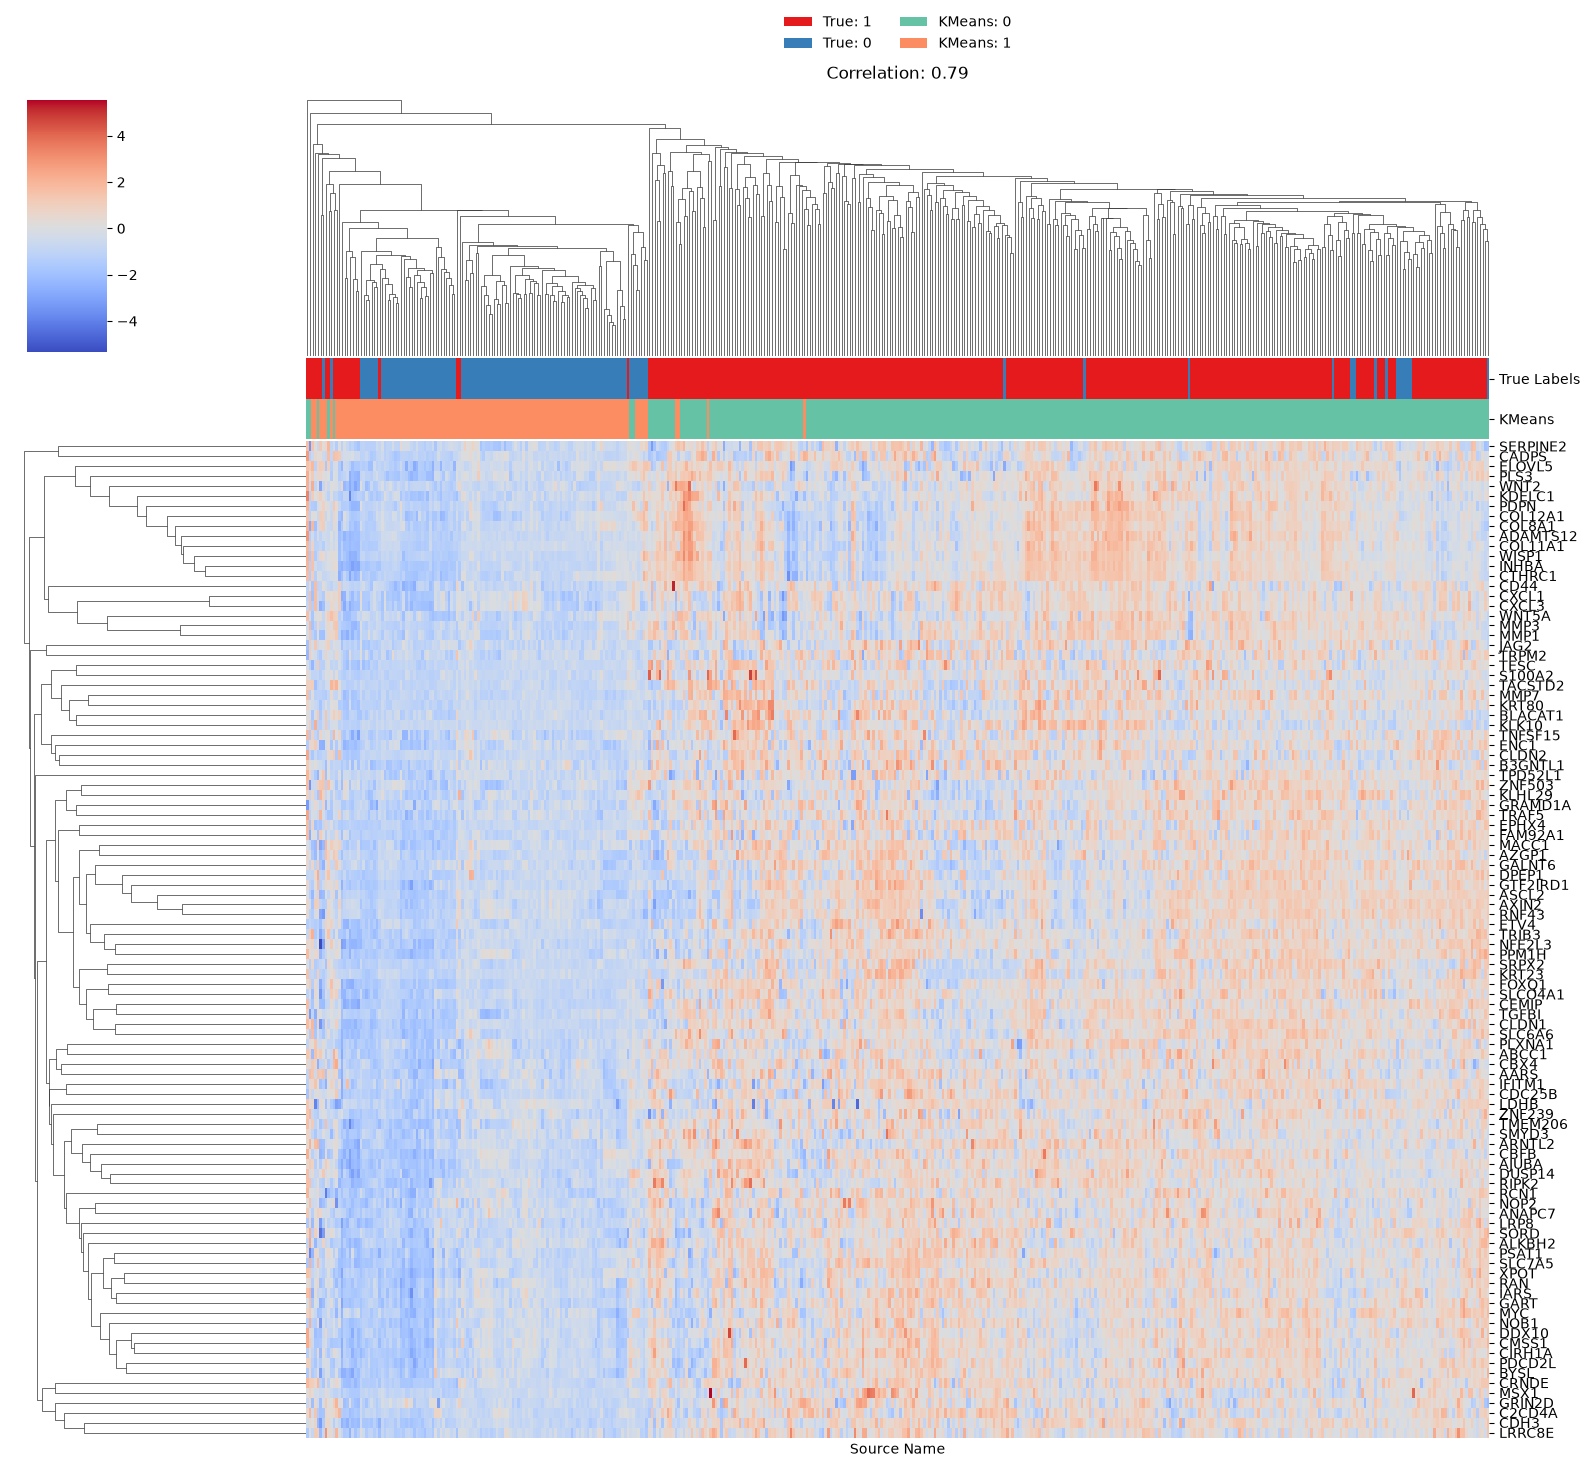

In [263]:
kmeans_labels = clustering_analysis(df_expression, top_genes, true_labels)

In [264]:
df_combined = true_labels.to_frame(name="true").join(kmeans_labels.to_frame(name="kmeans"))
df_combined.corr(method='pearson')

,true,kmeans
true,1.000000,-0.786374
kmeans,-0.786374,1.000000


### PCA

C:\Users\P70099789\AppData\Local\Temp\ipykernel_16848\4218652091.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="True label")


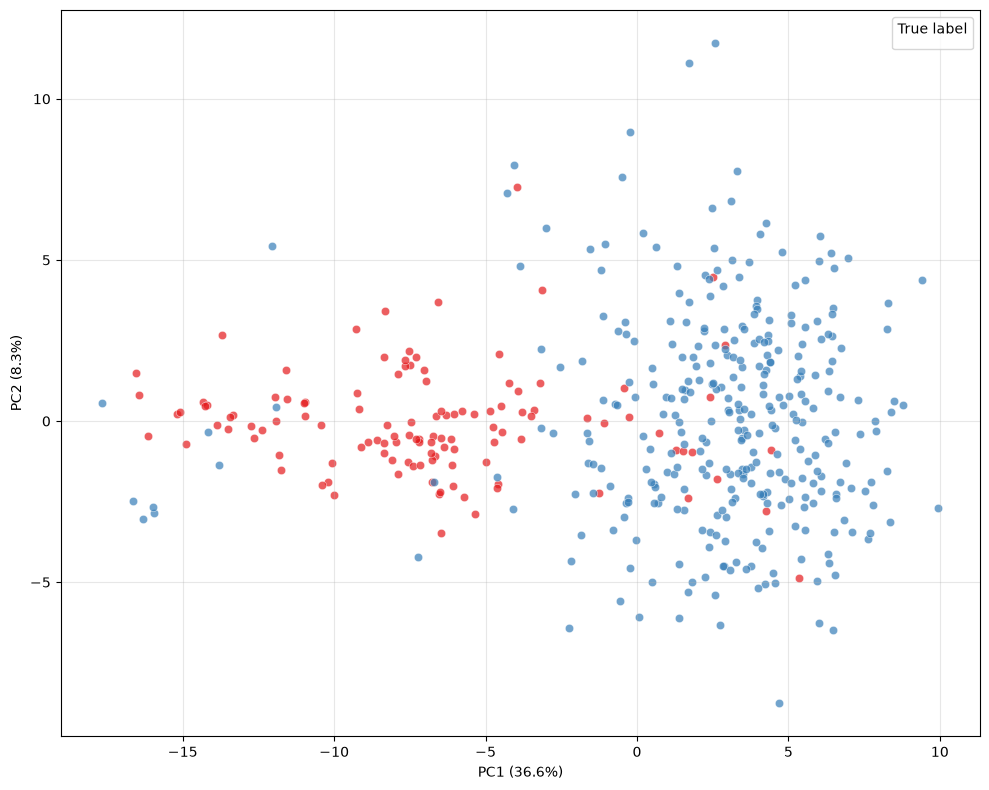

In [265]:
X_top = df_expression.loc[top_genes].T

X_top_scaled = StandardScaler().fit_transform(X_top)

pca_top = PCA(n_components=2)
X_pca_top = pca_top.fit_transform(X_top_scaled)

plt.figure(figsize=(10, 8))

for label, color in zip([0, 1, 2, 3], sns.color_palette("Set1", 4)):
    mask = true_labels.to_numpy() == label
    plt.scatter(
        X_pca_top[mask, 0],
        X_pca_top[mask, 1],
        color=color,
        alpha=0.7,
        edgecolor="white",
        linewidth=0.4,
    )

plt.xlabel(f"PC1 ({pca_top.explained_variance_ratio_[0] * 100:.1f}%)")
plt.ylabel(f"PC2 ({pca_top.explained_variance_ratio_[1] * 100:.1f}%)")
plt.legend(title="True label")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()